# MAVEN FUZZY FACTORY DATA ANALYSIS 

In [26]:
import pandas as pd

In [27]:
sessions_df   = pd.read_csv(r"D:\website_sessions.csv")

In [28]:
pageviews_df  = pd.read_csv(r"D:\website_pageviews.csv")

In [29]:
products_df   = pd.read_csv(r"D:\products.csv")

In [30]:
orders_df     = pd.read_csv(r"D:\orders.csv")

In [31]:
order_items_df = pd.read_csv(r"D:\order_items.csv")

In [32]:
refunds_df    = pd.read_csv(r"D:\order_item_refunds.csv")

In [33]:
data_dict_df  = pd.read_csv(r"D:\maven_fuzzy_factory_data_dictionary.csv")

In [34]:
df = pd.read_csv(r"D:\maven_fuzzy_factory_data_dictionary.csv")

In [35]:
df.head()

,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in t...


In [36]:
for name, d in [('sessions', sessions_df), ('pageviews', pageviews_df),
                 ('products', products_df), ('orders', orders_df),
                 ('order_items', order_items_df), ('refunds', refunds_df)]:
    print(f"--- {name} ---")
    print("shape:", d.shape)
    print("nulls:\n", d.isnull().sum()[d.isnull().sum() > 0])
    print("duplicates:", d.duplicated().sum())
    print()

--- sessions ---
shape: (472871, 9)
nulls:
 utm_source      83328
utm_campaign    83328
utm_content     83328
http_referer    39917
dtype: int64
duplicates: 0

--- pageviews ---
shape: (1048575, 4)
nulls:
 Series([], dtype: int64)
duplicates: 0

--- products ---
shape: (4, 3)
nulls:
 Series([], dtype: int64)
duplicates: 0

--- orders ---
shape: (32313, 8)
nulls:
 Series([], dtype: int64)
duplicates: 0

--- order_items ---
shape: (40025, 7)
nulls:
 Series([], dtype: int64)
duplicates: 0

--- refunds ---
shape: (1731, 5)
nulls:
 Series([], dtype: int64)
duplicates: 0



In [37]:
sessions_df['created_at']    = pd.to_datetime(sessions_df['created_at'], dayfirst=True)
pageviews_df['created_at']   = pd.to_datetime(pageviews_df['created_at'], dayfirst=True)
orders_df['created_at']      = pd.to_datetime(orders_df['created_at'], dayfirst=True)
order_items_df['created_at'] = pd.to_datetime(order_items_df['created_at'], dayfirst=True)
refunds_df['created_at']     = pd.to_datetime(refunds_df['created_at'], dayfirst=True)
products_df['created_at']    = pd.to_datetime(products_df['created_at'], dayfirst=True)

In [38]:
sessions_df['utm_source']   = sessions_df['utm_source'].fillna('direct')
sessions_df['utm_campaign'] = sessions_df['utm_campaign'].fillna('none')
sessions_df['utm_content']  = sessions_df['utm_content'].fillna('none')
sessions_df['http_referer'] = sessions_df['http_referer'].fillna('none')

In [39]:
for col in ['utm_source', 'utm_campaign', 'device_type']:
    sessions_df[col] = sessions_df[col].str.strip().str.lower()

In [40]:
sessions_df['device_type'] = sessions_df['device_type'].astype('category')
sessions_df['utm_source']  = sessions_df['utm_source'].astype('category')

In [41]:
orphan_orders  = orders_df[~orders_df['website_session_id'].isin(sessions_df['website_session_id'])]
orphan_items   = order_items_df[~order_items_df['order_id'].isin(orders_df['order_id'])]
orphan_refunds = refunds_df[~refunds_df['order_item_id'].isin(order_items_df['order_item_id'])]

print("Orphan orders:", len(orphan_orders))
print("Orphan order_items:", len(orphan_items))
print("Orphan refunds:", len(orphan_refunds))

Orphan orders: 0
Orphan order_items: 0
Orphan refunds: 0


In [42]:
print(order_items_df[['price_usd', 'cogs_usd']].describe())
print("Rows where cogs > price:", (order_items_df['cogs_usd'] > order_items_df['price_usd']).sum())

          price_usd      cogs_usd
count  40025.000000  40025.000000
mean      48.432473     18.047976
std        8.012370      3.856821
min       29.990000      9.490000
25%       49.990000     19.490000
50%       49.990000     19.490000
75%       49.990000     19.490000
max       59.990000     22.490000
Rows where cogs > price: 0


In [43]:
print("Max pageview date:", pageviews_df['created_at'].max())
print("Max session date:", sessions_df['created_at'].max())

Max pageview date: 2015-01-16 19:03:00
Max session date: 2015-03-19 07:59:00


In [47]:
import matplotlib.pyplot as plt

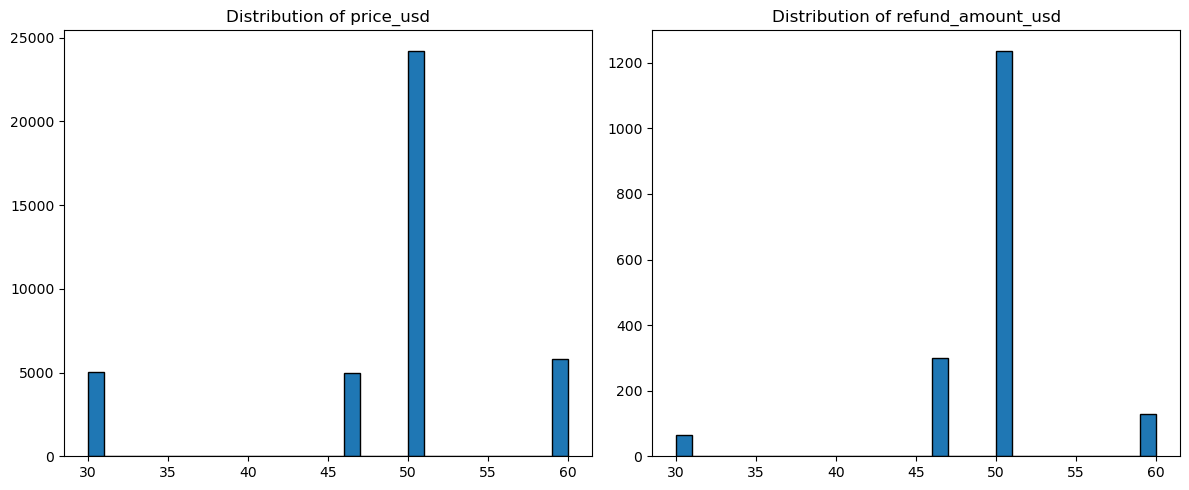

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(order_items_df['price_usd'], bins=30, edgecolor='black')
axes[0].set_title('Distribution of price_usd')

axes[1].hist(refunds_df['refund_amount_usd'], bins=30, edgecolor='black')
axes[1].set_title('Distribution of refund_amount_usd')

plt.tight_layout()
plt.show()

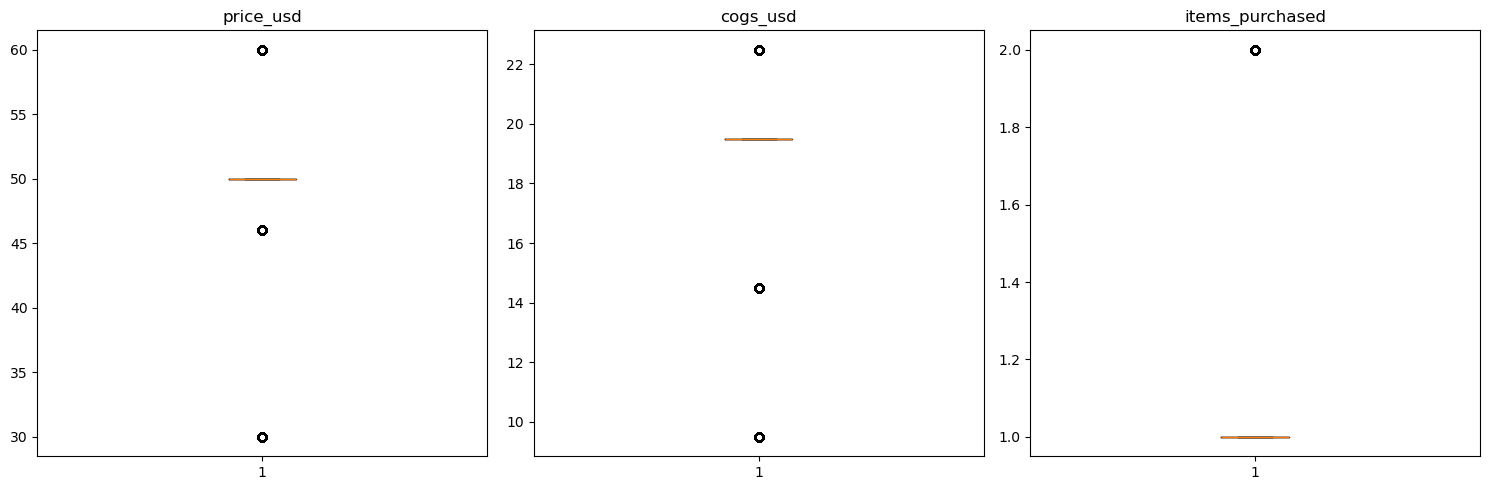

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(order_items_df['price_usd'])
axes[0].set_title('price_usd')

axes[1].boxplot(order_items_df['cogs_usd'])
axes[1].set_title('cogs_usd')

axes[2].boxplot(orders_df['items_purchased'])
axes[2].set_title('items_purchased')

plt.tight_layout()
plt.show()

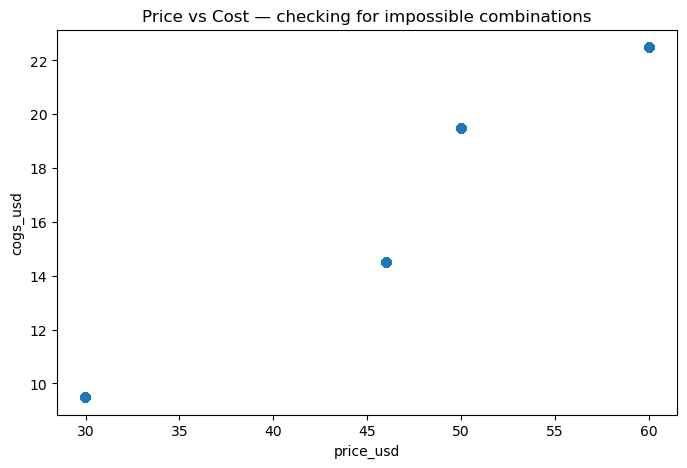

In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(order_items_df['price_usd'], order_items_df['cogs_usd'], alpha=0.3)
plt.xlabel('price_usd')
plt.ylabel('cogs_usd')
plt.title('Price vs Cost — checking for impossible combinations')
plt.show()

In [61]:
print(price_outliers[['order_item_id', 'price_usd', 'cogs_usd']])

       order_item_id  price_usd  cogs_usd
2661            2662      59.99     22.49
2662            2663      59.99     22.49
2681            2682      59.99     22.49
2682            2683      59.99     22.49
2687            2688      59.99     22.49
...              ...        ...       ...
40017          40018      45.99     14.49
40020          40021      29.99      9.49
40021          40022      59.99     22.49
40022          40023      29.99      9.49
40023          40024      29.99      9.49

[15799 rows x 3 columns]


In [62]:
# Re-run detection to get fresh outlier subsets
price_outliers = find_outliers_iqr(order_items_df, 'price_usd')
cogs_outliers = find_outliers_iqr(order_items_df, 'cogs_usd')
items_outliers = find_outliers_iqr(orders_df, 'items_purchased')
refund_outliers = find_outliers_iqr(refunds_df, 'refund_amount_usd')

# Look at them
print(price_outliers[['order_item_id', 'product_id', 'price_usd', 'cogs_usd']])
print(items_outliers[['order_id', 'items_purchased']])

price_usd: 15799 outliers found
  Normal range: 49.99 to 49.99
cogs_usd: 15799 outliers found
  Normal range: 19.49 to 19.49
items_purchased: 7712 outliers found
  Normal range: 1.00 to 1.00
refund_amount_usd: 494 outliers found
  Normal range: 49.99 to 49.99
       order_item_id  product_id  price_usd  cogs_usd
2661            2662           2      59.99     22.49
2662            2663           2      59.99     22.49
2681            2682           2      59.99     22.49
2682            2683           2      59.99     22.49
2687            2688           2      59.99     22.49
...              ...         ...        ...       ...
40017          40018           3      45.99     14.49
40020          40021           4      29.99      9.49
40021          40022           2      59.99     22.49
40022          40023           4      29.99      9.49
40023          40024           4      29.99      9.49

[15799 rows x 4 columns]
       order_id  items_purchased
7299       7300                2


In [66]:
# Getting the actual valid prices from your products table
valid_prices = products_df['price_usd'].unique() if 'price_usd' in products_df.columns else order_items_df.merge(products_df, on='product_id')['price_usd'].unique()
print("Valid prices:", sorted(valid_prices))

# Checking if any order_items price doesn't match ANY valid product price
invalid_price_rows = order_items_df[~order_items_df['price_usd'].isin(valid_prices)]
print(f"Genuinely invalid prices: {len(invalid_price_rows)}")

Valid prices: [np.float64(29.99), np.float64(45.99), np.float64(49.99), np.float64(59.99)]
Genuinely invalid prices: 0


In [68]:
valid_cogs = order_items_df.merge(products_df, on='product_id')['cogs_usd_y'].unique() if 'cogs_usd' in products_df.columns else None
# Or simpler: just check cogs_usd per product_id is consistent
print(order_items_df.groupby('product_id')['cogs_usd'].unique())

product_id
1    [19.49]
2    [22.49]
3    [14.49]
4     [9.49]
Name: cogs_usd, dtype: object


In [69]:
refund_check = refunds_df.merge(order_items_df, on='order_item_id')
mismatched_refunds = refund_check[refund_check['refund_amount_usd'] > refund_check['price_usd']]
print(f"Refunds exceeding the item's price: {len(mismatched_refunds)}")

Refunds exceeding the item's price: 0


In [71]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ---- 1. EXPANDED GEO LOOKUP: 20 US states + 4 UK nations ----
geo_data = {
    'United States': {
        'California': ['Los Angeles', 'San Francisco', 'San Diego', 'Sacramento'],
        'New York': ['New York City', 'Buffalo', 'Albany', 'Rochester'],
        'Texas': ['Houston', 'Austin', 'Dallas', 'San Antonio'],
        'Florida': ['Miami', 'Orlando', 'Tampa', 'Jacksonville'],
        'Illinois': ['Chicago', 'Springfield', 'Naperville', 'Peoria'],
        'Washington': ['Seattle', 'Spokane', 'Tacoma', 'Bellevue'],
        'Georgia': ['Atlanta', 'Savannah', 'Augusta', 'Columbus'],
        'Pennsylvania': ['Philadelphia', 'Pittsburgh', 'Allentown', 'Erie'],
        'Ohio': ['Columbus', 'Cleveland', 'Cincinnati', 'Toledo'],
        'Arizona': ['Phoenix', 'Tucson', 'Mesa', 'Scottsdale'],
        'Massachusetts': ['Boston', 'Worcester', 'Springfield', 'Cambridge'],
        'Michigan': ['Detroit', 'Grand Rapids', 'Ann Arbor', 'Lansing'],
        'North Carolina': ['Charlotte', 'Raleigh', 'Durham', 'Greensboro'],
        'Colorado': ['Denver', 'Colorado Springs', 'Boulder', 'Aurora'],
        'Nevada': ['Las Vegas', 'Reno', 'Henderson', 'Carson City'],
        'Oregon': ['Portland', 'Eugene', 'Salem', 'Bend'],
        'Tennessee': ['Nashville', 'Memphis', 'Knoxville', 'Chattanooga'],
        'Virginia': ['Richmond', 'Virginia Beach', 'Norfolk', 'Arlington'],
        'New Jersey': ['Newark', 'Jersey City', 'Trenton', 'Princeton'],
        'Minnesota': ['Minneapolis', 'Saint Paul', 'Rochester', 'Duluth'],
    },
    'United Kingdom': {
        'England': ['London', 'Manchester', 'Birmingham', 'Liverpool', 'Leeds', 'Bristol', 'Sheffield', 'Newcastle'],
        'Scotland': ['Edinburgh', 'Glasgow', 'Aberdeen', 'Dundee', 'Inverness', 'Stirling'],
        'Wales': ['Cardiff', 'Swansea', 'Newport', 'Wrexham', 'Bangor'],
        'Northern Ireland': ['Belfast', 'Derry', 'Lisburn', 'Newry', 'Armagh'],
    }
}

# ---- 2. FLATTEN INTO LOOKUP TABLE ----
geo_rows = []
for country, regions in geo_data.items():
    for region, cities in regions.items():
        for city in cities:
            geo_rows.append({'country': country, 'region': region, 'city': city})

geo_lookup = pd.DataFrame(geo_rows)
print(f"Total valid geo combinations: {len(geo_lookup)}")
print(f"US states: {len(geo_data['United States'])} | UK nations: {len(geo_data['United Kingdom'])}")


# ---- 3. ASSIGN COUNTRY (weighted) ----
country_weights = {'United States': 0.75, 'United Kingdom': 0.25}
sessions_df['country'] = np.random.choice(
    list(country_weights.keys()), size=len(sessions_df), p=list(country_weights.values())
)

# ---- 4. ASSIGN VALID REGION + CITY PER ROW ----
def assign_region_city(country):
    subset = geo_lookup[geo_lookup['country'] == country]
    chosen = subset.sample(1).iloc[0]
    return chosen['region'], chosen['city']

regions, cities = [], []
for country in sessions_df['country']:
    r, c = assign_region_city(country)
    regions.append(r)
    cities.append(c)

sessions_df['region'] = regions
sessions_df['city'] = cities


# ---- 5. STANDARDIZE + CONVERT TO CATEGORY ----
for col in ['country', 'region', 'city']:
    sessions_df[col] = sessions_df[col].str.strip().str.title().astype('category')


# ---- 6. VALIDATION ----
print("\nNulls in geo columns:")
print(sessions_df[['country', 'region', 'city']].isnull().sum())

print("\nRow count check:", len(sessions_df))  # must still be 472,871
print("Duplicate session_ids:", sessions_df['website_session_id'].duplicated().sum())  # must still be 0

print("\nRegions found per country (sanity check — no cross-country mismatches):")
print(sessions_df.groupby('country')['region'].unique())

print("\nSession count by country:")
print(sessions_df['country'].value_counts())

print("\nSample rows:")
print(sessions_df[['website_session_id', 'country', 'region', 'city']].sample(10))


# ---- 7. EXPORT ----
sessions_df.to_csv(r"D:\powerbi_sessions.csv", index=False)
print("\nSaved to D:\\powerbi_sessions.csv")

Total valid geo combinations: 104
US states: 20 | UK nations: 4

Nulls in geo columns:
country    0
region     0
city       0
dtype: int64

Row count check: 472871
Duplicate session_ids: 0

Regions found per country (sanity check — no cross-country mismatches):
country
United Kingdom    ['England', 'Scotland', 'Wales', 'Northern Ire...
United States     ['New Jersey', 'Minnesota', 'Georgia', 'Pennsy...
Name: region, dtype: object

Session count by country:
country
United States     354750
United Kingdom    118121
Name: count, dtype: int64

Sample rows:
        website_session_id        country          region        city
285531              285532  United States        Virginia    Richmond
122591              122592  United States      Washington    Bellevue
342397              342398  United States    Pennsylvania        Erie
179616              179617  United States   Massachusetts   Worcester
348644              348645  United States        Michigan     Lansing
337996              3

C:\Users\hp\AppData\Local\Temp\ipykernel_17128\1314151055.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sessions_df.groupby('country')['region'].unique())



Saved to D:\powerbi_sessions.csv


In [75]:
print(sessions_df['country'].value_counts())
print(sessions_df['country'].value_counts(normalize=True))  # as percentages

country
United States     354750
United Kingdom    118121
Name: count, dtype: int64
country
United States     0.750205
United Kingdom    0.249795
Name: proportion, dtype: float64


In [80]:
# Remove geo columns from tables that shouldn't have them
orders_df = orders_df.drop(columns=['country', 'region', 'city'], errors='ignore')
order_items_df = order_items_df.drop(columns=['country', 'region', 'city'], errors='ignore')
refunds_df = refunds_df.drop(columns=['country', 'region', 'city'], errors='ignore')
pageviews_df = pageviews_df.drop(columns=['country', 'region', 'city'], errors='ignore')

# Confirm only sessions_df still has them
print("orders_df columns:", orders_df.columns.tolist())
print("sessions_df columns:", sessions_df.columns.tolist())

orders_df columns: ['order_id', 'created_at', 'website_session_id', 'user_id', 'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd']
sessions_df columns: ['website_session_id', 'created_at', 'user_id', 'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer', 'country', 'region', 'city']


In [81]:
sessions_df.to_csv(r"D:\clean_website_sessions.csv", index=False)
pageviews_df.to_csv(r"D:\clean_website_pageviews.csv", index=False)
orders_df.to_csv(r"D:\clean_orders.csv", index=False)
order_items_df.to_csv(r"D:\clean_order_items.csv", index=False)
refunds_df.to_csv(r"D:\clean_order_item_refunds.csv", index=False)
products_df.to_csv(r"D:\clean_products.csv", index=False)

In [82]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [83]:
with pd.ExcelWriter(r"D:\maven_fuzzy_factory_cleaned.xlsx", engine='openpyxl') as writer:
    sessions_df.to_excel(writer, sheet_name='website_sessions', index=False)
    orders_df.to_excel(writer, sheet_name='orders', index=False)
    order_items_df.to_excel(writer, sheet_name='order_items', index=False)
    refunds_df.to_excel(writer, sheet_name='order_item_refunds', index=False)
    products_df.to_excel(writer, sheet_name='products', index=False)

In [76]:
# pageviews → CSV (too close to Excel's row limit)
pageviews_df.to_csv(r"D:\clean_website_pageviews.csv", index=False)

print("All files saved successfully.")

All files saved successfully.


In [77]:
import pandas as pd

# Standard US Census Bureau 4-region breakdown
state_region_map = {
    # Northeast
    'New York': 'Northeast', 'Massachusetts': 'Northeast', 'New Jersey': 'Northeast', 'Pennsylvania': 'Northeast',
    # Midwest
    'Illinois': 'Midwest', 'Ohio': 'Midwest', 'Michigan': 'Midwest', 'Minnesota': 'Midwest',
    # South
    'Texas': 'South', 'Florida': 'South', 'Georgia': 'South', 'North Carolina': 'South',
    'Tennessee': 'South', 'Virginia': 'South',
    # West
    'California': 'West', 'Washington': 'West', 'Arizona': 'West', 'Colorado': 'West',
    'Nevada': 'West', 'Oregon': 'West',
}

# Build as a clean lookup DataFrame
us_region_lookup = pd.DataFrame(list(state_region_map.items()), columns=['state', 'us_census_region'])
print(us_region_lookup)

# Export as its own standalone CSV — this becomes a new table in Power BI
us_region_lookup.to_csv(r"D:\powerbi_us_region_lookup.csv", index=False)

             state us_census_region
0         New York        Northeast
1    Massachusetts        Northeast
2       New Jersey        Northeast
3     Pennsylvania        Northeast
4         Illinois          Midwest
5             Ohio          Midwest
6         Michigan          Midwest
7        Minnesota          Midwest
8            Texas            South
9          Florida            South
10         Georgia            South
11  North Carolina            South
12       Tennessee            South
13        Virginia            South
14      California             West
15      Washington             West
16         Arizona             West
17        Colorado             West
18          Nevada             West
19          Oregon             West


In [78]:
import pandas as pd

# ---- US Census Bureau 4-region breakdown (official, standard classification) ----
state_region_map = {
    # Northeast
    'New York': 'Northeast',
    'Massachusetts': 'Northeast',
    'New Jersey': 'Northeast',
    'Pennsylvania': 'Northeast',
    # Midwest
    'Illinois': 'Midwest',
    'Ohio': 'Midwest',
    'Michigan': 'Midwest',
    'Minnesota': 'Midwest',
    # South
    'Texas': 'South',
    'Florida': 'South',
    'Georgia': 'South',
    'North Carolina': 'South',
    'Tennessee': 'South',
    'Virginia': 'South',
    # West
    'California': 'West',
    'Washington': 'West',
    'Arizona': 'West',
    'Colorado': 'West',
    'Nevada': 'West',
    'Oregon': 'West',
}

us_region_lookup = pd.DataFrame(
    list(state_region_map.items()), columns=['state', 'us_census_region']
)

print("Total US states mapped:", len(us_region_lookup))
print(us_region_lookup)
print("\nStates per region:")
print(us_region_lookup['us_census_region'].value_counts())

us_region_lookup.to_csv(r"D:\powerbi_us_region_lookup.csv", index=False)
print("\nSaved to D:\\powerbi_us_region_lookup.csv")

Total US states mapped: 20
             state us_census_region
0         New York        Northeast
1    Massachusetts        Northeast
2       New Jersey        Northeast
3     Pennsylvania        Northeast
4         Illinois          Midwest
5             Ohio          Midwest
6         Michigan          Midwest
7        Minnesota          Midwest
8            Texas            South
9          Florida            South
10         Georgia            South
11  North Carolina            South
12       Tennessee            South
13        Virginia            South
14      California             West
15      Washington             West
16         Arizona             West
17        Colorado             West
18          Nevada             West
19          Oregon             West

States per region:
us_census_region
South        6
West         6
Northeast    4
Midwest      4
Name: count, dtype: int64

Saved to D:\powerbi_us_region_lookup.csv
